In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("merged_df_raw.csv")

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nSummary stats (numeric columns):")
df.describe()

Shape: (1658965, 40)

Dtypes:
REGION                             object
SETTLEMENTDATE                     object
TOTALDEMAND                       float64
RRP                               float64
PERIODTYPE                         object
station_number                    float64
year_local                        float64
month_local                       float64
day_local                         float64
hour_local                        float64
minute_local                      float64
year_std                          float64
month_std                         float64
day_std                           float64
hour_std                          float64
minute_std                        float64
precipitation_9am_mm              float64
precipitation_quality              object
air_temperature_c                 float64
air_temperature_quality            object
wet_bulb_temp_c                   float64
wet_bulb_quality                   object
dew_point_temp_c                  float64
dew_

,TOTALDEMAND,RRP,station_number,year_local,month_local,day_local,hour_local,minute_local,year_std,month_std,...,dew_point_temp_c,relative_humidity_pct,wind_speed_kmh,wind_direction_deg,max_gust_kmh,mslp_hpa,station_level_pressure_hpa,aws_flag,latitude,longitude
count,1.658965e+06,1.658965e+06,1.651283e+06,1.651283e+06,1.651283e+06,1.651283e+06,1.651283e+06,1.651283e+06,1.651283e+06,1.651283e+06,...,1.649897e+06,1.649895e+06,1.238046e+06,1.236894e+06,1.211741e+06,1.648923e+06,1.648383e+06,1.612103e+06,1.651283e+06,1.651283e+06
mean,4.619879e+03,5.142330e+01,6.021096e+04,2.009928e+03,6.532510e+00,1.573475e+01,1.149949e+01,1.499716e+01,2.009928e+03,6.533028e+00,...,9.892738e+00,6.518546e+01,1.009905e+01,1.757392e+02,1.748023e+01,1.016619e+03,1.012563e+03,9.999988e-01,-3.496289e+01,1.470197e+02
std,2.848202e+03,1.912126e+02,2.638102e+04,5.636511e+00,3.448089e+00,8.791044e+00,6.924821e+00,1.500000e+01,5.636496e+00,3.448132e+00,...,5.535655e+00,1.868928e+01,7.346314e+00,1.143524e+02,1.105936e+01,7.490337e+00,7.804811e+00,4.167568e-03,4.849177e+00,5.213857e+00
min,2.189000e+01,-1.000000e+03,2.309000e+04,2.000000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.000000e+03,1.000000e+00,...,-2.820000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.753000e+02,9.693000e+02,0.000000e+00,-4.288970e+01,1.386216e+02
25%,1.414270e+03,2.334000e+01,4.091300e+04,2.005000e+03,4.000000e+00,8.000000e+00,5.000000e+00,0.000000e+00,2.005000e+03,4.000000e+00,...,5.800000e+00,5.300000e+01,5.400000e+00,7.000000e+01,9.400000e+00,1.012000e+03,1.007800e+03,1.000000e+00,-3.780750e+01,1.449700e+02
50%,5.131463e+03,3.441000e+01,6.606200e+04,2.010000e+03,7.000000e+00,1.600000e+01,1.100000e+01,0.000000e+00,2.010000e+03,7.000000e+00,...,9.500000e+00,6.700000e+01,9.400000e+00,1.900000e+02,1.480000e+01,1.016900e+03,1.013100e+03,1.000000e+00,-3.492110e+01,1.473278e+02
75%,6.591495e+03,5.487000e+01,8.607100e+04,2.015000e+03,1.000000e+01,2.300000e+01,1.800000e+01,3.000000e+01,2.015000e+03,1.000000e+01,...,1.400000e+01,8.000000e+01,1.480000e+01,2.700000e+02,2.410000e+01,1.021700e+03,1.017900e+03,1.000000e+00,-3.386070e+01,1.512050e+02
max,1.457986e+04,1.470000e+04,9.402900e+04,2.020000e+03,1.200000e+01,3.100000e+01,2.300000e+01,3.000000e+01,2.020000e+03,1.200000e+01,...,4.100000e+01,1.030000e+02,8.140000e+01,3.600000e+02,1.278000e+02,1.041800e+03,1.037600e+03,2.000000e+00,-2.748080e+01,1.530389e+02


In [2]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().sum() / len(df) * 100).round(2),
}).sort_values("missing_pct", ascending=False)

print(missing_summary)

                                missing_count  missing_pct
max_gust_kmh                           447224        26.96
max_gust_quality                       447224        26.96
wind_direction_quality                 421960        25.44
wind_direction_deg                     422071        25.44
wind_speed_kmh                         420919        25.37
wind_speed_quality                     420919        25.37
aws_flag                                46862         2.82
precipitation_quality                   18854         1.14
precipitation_9am_mm                    18854         1.14
wet_bulb_quality                        10891         0.66
wet_bulb_temp_c                         10891         0.66
station_level_pressure_hpa              10582         0.64
station_level_pressure_quality          10582         0.64
mslp_hpa                                10042         0.61
mslp_quality                            10042         0.61
dew_point_quality                        9068         0.

In [3]:
quality_cols = [c for c in df.columns if "quality" in c]

for col in quality_cols:
    print(col, "->", df[col].dropna().unique())

precipitation_quality -> ['N']
air_temperature_quality -> ['N']
wet_bulb_quality -> ['N']
dew_point_quality -> ['N']
relative_humidity_quality -> ['N']
wind_speed_quality -> ['N']
wind_direction_quality -> ['N']
max_gust_quality -> ['N']
mslp_quality -> ['N']
station_level_pressure_quality -> ['N']


In [4]:
df_clean = df.drop(columns=quality_cols)

# PERIODTYPE is 100% "TRADE" (confirmed earlier) -- no information
df_clean = df_clean.drop(columns=["PERIODTYPE"])

print("Remaining columns:", df_clean.columns.tolist())

Remaining columns: ['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'station_number', 'year_local', 'month_local', 'day_local', 'hour_local', 'minute_local', 'year_std', 'month_std', 'day_std', 'hour_std', 'minute_std', 'precipitation_9am_mm', 'air_temperature_c', 'wet_bulb_temp_c', 'dew_point_temp_c', 'relative_humidity_pct', 'wind_speed_kmh', 'wind_direction_deg', 'max_gust_kmh', 'mslp_hpa', 'station_level_pressure_hpa', 'aws_flag', 'station_name', 'latitude', 'longitude']


In [5]:
#HANDLING MISSING VALUES FOR ESSENTIAL COLUMNS SUCH AS TOTAL DEMAND AIR TEMP AND RELATIVE HUMIDITY 
# Only require the columns central to this research question to be non-null.
# Wind/gust/precipitation aren't part of the temperature-demand analysis, so
# their gaps (including the large ~25% wind gap) don't need rows dropped for them.
essential_cols = ["TOTALDEMAND", "air_temperature_c", "relative_humidity_pct"]

before = len(df_clean)
df_clean = df_clean.dropna(subset=essential_cols)
after = len(df_clean)

print(f"Dropped {before - after} rows ({(before - after) / before * 100:.2f}%)")
print(f"Remaining rows: {after}")

Dropped 9070 rows (0.55%)
Remaining rows: 1649895


In [6]:
#FEATURE ENGINEERING FOR THE RESEARCH QUESTION 
df_clean["SETTLEMENTDATE"] = pd.to_datetime(df_clean["SETTLEMENTDATE"]) #double check correct format

region_to_state = {"NSW1": "NSW", "VIC1": "VIC", "QLD1": "QLD", "SA1": "SA", "TAS1": "TAS"}
df_clean["state"] = df_clean["REGION"].map(region_to_state)

# Time-based features -- needed to control for known confounders (RQ3-adjacent)
df_clean["hour"] = df_clean["SETTLEMENTDATE"].dt.hour
df_clean["day_of_week"] = df_clean["SETTLEMENTDATE"].dt.dayofweek  # 0=Monday
df_clean["is_weekend"] = df_clean["day_of_week"].isin([5, 6])
df_clean["month"] = df_clean["SETTLEMENTDATE"].dt.month
df_clean["year"] = df_clean["SETTLEMENTDATE"].dt.year

# Demand anomaly: z-score per state, so states are comparable on the same scale
# (raw MW isn't comparable -- NSW's demand dwarfs TAS's)
from sklearn.preprocessing import StandardScaler

df_clean["demand_zscore"] = df_clean.groupby("state")["TOTALDEMAND"].transform(
    lambda x: StandardScaler().fit_transform(x.values.reshape(-1, 1)).flatten()
)

In [7]:
#FEATURE SELECTION BASED ON RESEARCH QUESTION TARGETS
# Only the columns relevant to "does temperature sensitivity of demand
# differ between states" -- drops wind/gust/pressure/precipitation
# (not part of this RQ, and wind/gust have ~25% missingness anyway)
rq_features = [
    "SETTLEMENTDATE", "state",
    "TOTALDEMAND", "demand_zscore",       # target
    "air_temperature_c",                    # primary explanatory variable
    "relative_humidity_pct",                # confound / secondary explanatory variable
    "hour", "day_of_week", "is_weekend", "month", "year",  # confounders to control for
    "station_name", "latitude", "longitude",  # for the map visual only, not modelling
]


df_rq = df_clean[rq_features].copy()

print(df_rq.shape)
df_rq.head()

(1649895, 14)


,SETTLEMENTDATE,state,TOTALDEMAND,demand_zscore,air_temperature_c,relative_humidity_pct,hour,day_of_week,is_weekend,month,year,station_name,latitude,longitude
0,2000-09-01 00:30:00,NSW,8117.23667,-0.155289,13.7,54.0,0,4,False,9,2000,SYDNEY (OBSERVATORY HILL),-33.8607,151.205
1,2000-09-01 01:00:00,NSW,7799.70000,-0.389350,13.6,53.0,1,4,False,9,2000,SYDNEY (OBSERVATORY HILL),-33.8607,151.205
2,2000-09-01 01:30:00,NSW,7453.99000,-0.644179,13.4,55.0,1,4,False,9,2000,SYDNEY (OBSERVATORY HILL),-33.8607,151.205
3,2000-09-01 02:00:00,NSW,7095.55333,-0.908388,13.5,52.0,2,4,False,9,2000,SYDNEY (OBSERVATORY HILL),-33.8607,151.205
4,2000-09-01 02:30:00,NSW,6786.22167,-1.136402,13.6,50.0,2,4,False,9,2000,SYDNEY (OBSERVATORY HILL),-33.8607,151.205


In [8]:
print("Final shape:", df_rq.shape)
print("\nMissing values:", df_rq.isna().sum().sum())
print("\nRows per state:")
print(df_rq["state"].value_counts())
print("\nDate range:", df_rq["SETTLEMENTDATE"].min(), "to", df_rq["SETTLEMENTDATE"].max())


Final shape: (1649895, 14)

Missing values: 0

Rows per state:
state
NSW    349560
QLD    348877
SA     348770
VIC    347801
TAS    254887
Name: count, dtype: int64

Date range: 2000-01-01 00:30:00 to 2020-01-01 00:00:00


In [9]:
df_rq.info()
df_rq.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1649895 entries, 0 to 1658964
Data columns (total 14 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   SETTLEMENTDATE         1649895 non-null  datetime64[ns]
 1   state                  1649895 non-null  object        
 2   TOTALDEMAND            1649895 non-null  float64       
 3   demand_zscore          1649895 non-null  float64       
 4   air_temperature_c      1649895 non-null  float64       
 5   relative_humidity_pct  1649895 non-null  float64       
 6   hour                   1649895 non-null  int32         
 7   day_of_week            1649895 non-null  int32         
 8   is_weekend             1649895 non-null  bool          
 9   month                  1649895 non-null  int32         
 10  year                   1649895 non-null  int32         
 11  station_name           1649895 non-null  object        
 12  latitude               1649895 no

,SETTLEMENTDATE,TOTALDEMAND,demand_zscore,air_temperature_c,relative_humidity_pct,hour,day_of_week,month,year,latitude,longitude
count,1649895,1.649895e+06,1.649895e+06,1.649895e+06,1.649895e+06,1.649895e+06,1.649895e+06,1.649895e+06,1.649895e+06,1.649895e+06,1.649895e+06
mean,2010-06-07 02:54:20.678407168,4.621715e+03,6.504679e-17,1.729629e+01,6.518546e+01,1.150009e+01,3.000229e+00,6.533879e+00,2.009930e+03,-3.496392e+01,1.470203e+02
min,2000-01-01 00:30:00,2.189000e+01,-4.617010e+00,-3.000000e-01,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+03,-4.288970e+01,1.386216e+02
25%,2005-10-30 03:00:00,1.414330e+03,-7.263728e-01,1.280000e+01,5.300000e+01,5.000000e+00,1.000000e+00,4.000000e+00,2.005000e+03,-3.780750e+01,1.449700e+02
50%,2010-07-21 23:30:00,5.132810e+03,-5.683448e-02,1.690000e+01,6.700000e+01,1.100000e+01,3.000000e+00,7.000000e+00,2.010000e+03,-3.492110e+01,1.473278e+02
75%,2015-04-16 06:00:00,6.594600e+03,6.525504e-01,2.140000e+01,8.000000e+01,1.800000e+01,5.000000e+00,1.000000e+01,2.015000e+03,-3.386070e+01,1.512050e+02
max,2020-01-01 00:00:00,1.457986e+04,6.308622e+00,4.740000e+01,1.030000e+02,2.300000e+01,6.000000e+00,1.200000e+01,2.020000e+03,-2.748080e+01,1.530389e+02
std,NaN,2.849574e+03,1.000000e+00,6.074258e+00,1.868928e+01,6.924890e+00,1.999471e+00,3.448180e+00,5.636551e+00,4.849262e+00,5.213277e+00


## Exploratory groundwork: additional engineered columns

These build directly on `df_rq` (rather than `df_clean`) since they're specific to this research question's EDA, not part of the general preprocessing pipeline.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

In [18]:
# Season (Southern Hemisphere) -- included as a confound check, even though it's
# not the core RQ, since it costs one line and rules out "state differences are
# just a seasonal mix artefact"
season_map = {12: "Summer", 1: "Summer", 2: "Summer",
              3: "Autumn", 4: "Autumn", 5: "Autumn",
              6: "Winter", 7: "Winter", 8: "Winter",
              9: "Spring", 10: "Spring", 11: "Spring"}
df_rq["season"] = df_rq["month"].map(season_map)

# High-demand flag: top quartile WITHIN each state (keeps the state-normalisation
# used for demand_zscore -- "high demand" means high relative to that state's own
# norm, not high in absolute MW)
df_rq["high_demand"] = df_rq.groupby("state")["TOTALDEMAND"].transform(
    lambda x: x >= x.quantile(0.75)
)

# Temperature deviation from each state's OWN average. 30C is "extreme" in TAS
# but unremarkable in QLD, so this expresses temperature relative to what's
# normal for that state, making cross-state sensitivity comparisons fairer.
# NOTE: with_std=False -- this only mean-centres (keeps original degC units),
# unlike demand_zscore above which is a full standardisation (mean 0, std 1).
# Using default StandardScaler() here would compute a second z-score, not a
# degC deviation, which isn't what "temperature deviation" should represent.
df_rq["temp_deviation"] = df_rq.groupby("state")["air_temperature_c"].transform(
    lambda x: StandardScaler(with_std=False).fit_transform(x.values.reshape(-1, 1)).flatten()
)

df_rq[["season", "high_demand", "temp_deviation"]].describe(include="all")

,season,high_demand,temp_deviation
count,1649895,1649895,1.649895e+06
unique,4,2,NaN
top,Winter,False,NaN
freq,418224,1237419,NaN
mean,NaN,NaN,-2.645971e-17
std,NaN,NaN,5.533656e+00
min,NaN,NaN,-1.781397e+01
25%,NaN,NaN,-3.902315e+00
50%,NaN,NaN,-3.139691e-01
75%,NaN,NaN,3.420136e+00


### Box plots: raw vs. normalised, to show why normalisation was necessary

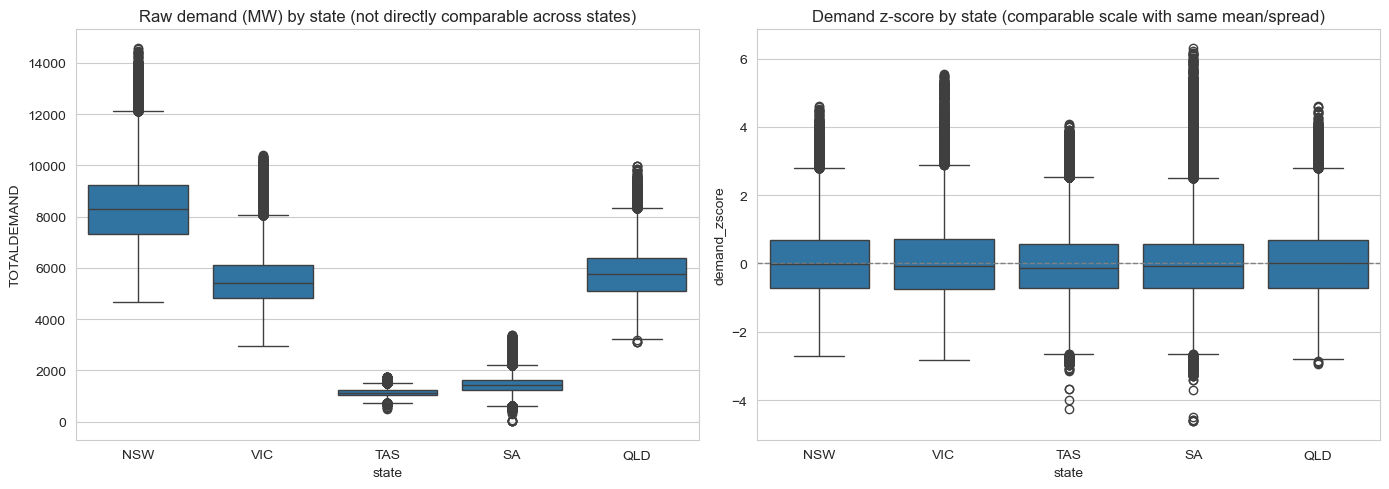

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_rq, x="state", y="TOTALDEMAND", ax=axes[0])
axes[0].set_title("Raw demand (MW) by state (not directly comparable across states)")

sns.boxplot(data=df_rq, x="state", y="demand_zscore", ax=axes[1])
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Demand z-score by state (comparable scale with same mean/spread)")

plt.tight_layout()
plt.show()

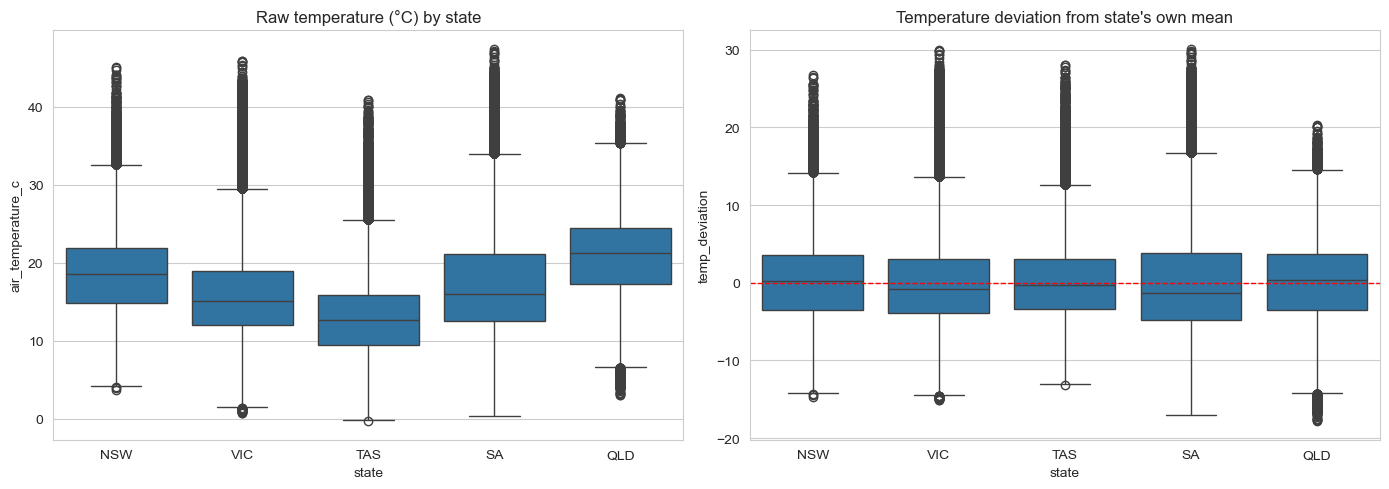

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_rq, x="state", y="air_temperature_c", ax=axes[0])
axes[0].set_title("Raw temperature (\u00b0C) by state")

sns.boxplot(data=df_rq, x="state", y="temp_deviation", ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Temperature deviation from state's own mean")

plt.tight_layout()
plt.show()

### temperature vs. demand, faceted by state


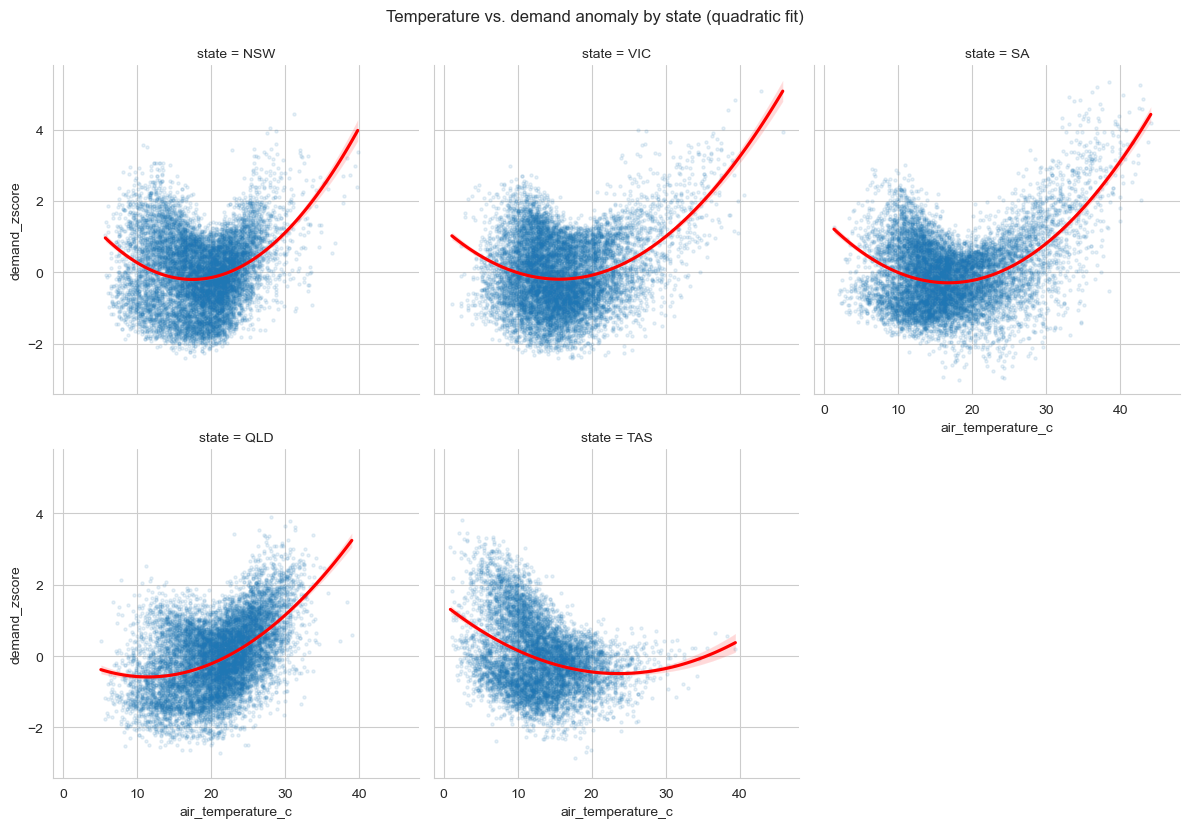

In [25]:
sample_df = df_rq.sample(50_000, random_state=42)  # sample for plotting speed -- 1.6M points will crawl/overplot

temp_demand_facets = sns.lmplot(
    data=sample_df, x="air_temperature_c", y="demand_zscore",
    col="state", col_wrap=3,
    order=2,  # quadratic fit -- matches the U-shaped relationship
    scatter_kws={"alpha": 0.1, "s": 5},
    line_kws={"color": "red"},
    height=4,
)
temp_demand_facets.fig.suptitle("Temperature vs. demand anomaly by state (quadratic fit)", y=1.03)
plt.show()

### Confounder check: same relationship, split by weekday/weekend

If a state's curve shape changes noticeably between weekday and weekend, that's a real confounder to keep controlling for (already covered by `day_of_week`/`is_weekend` in the feature set). If curves look similar across both rows, that's reassurance the state differences aren't just a weekday/weekend mix artefact.

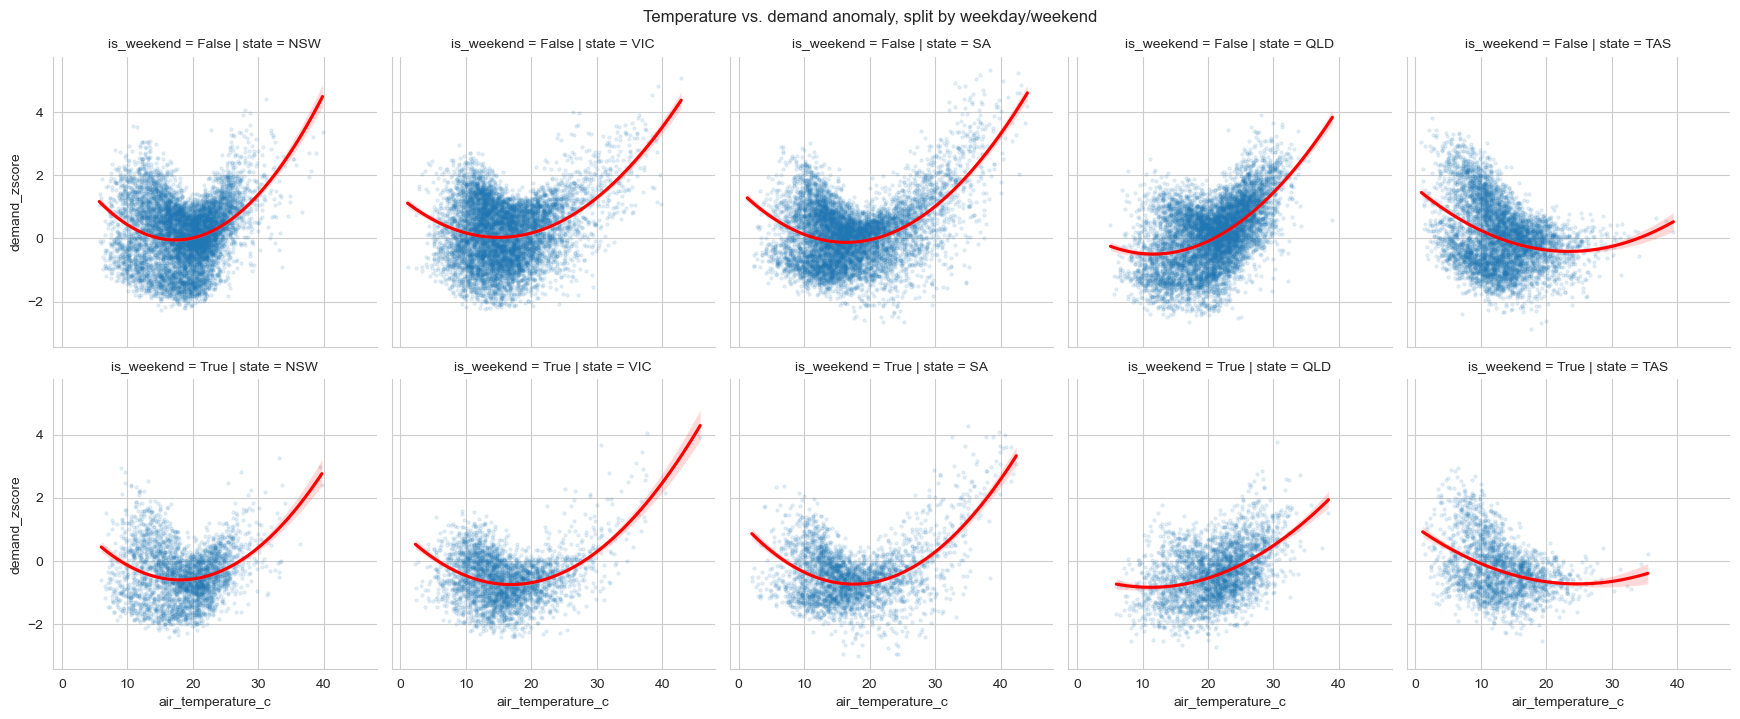

In [27]:
weekday_weekend_facets = sns.lmplot(
    data=sample_df, x="air_temperature_c", y="demand_zscore",
    col="state", row="is_weekend",
    order=2,
    scatter_kws={"alpha": 0.1, "s": 5},
    line_kws={"color": "red"},
    height=3.5,
)
weekday_weekend_facets.fig.suptitle("Temperature vs. demand anomaly, split by weekday/weekend", y=1.02)
plt.show()

### Does reframing temperature as a deviation actually help?

If the curves overlap more in the right-hand plot than the left, that's evidence some apparent "state differences" were really just each state having a different climate baseline, not a different underlying sensitivity.

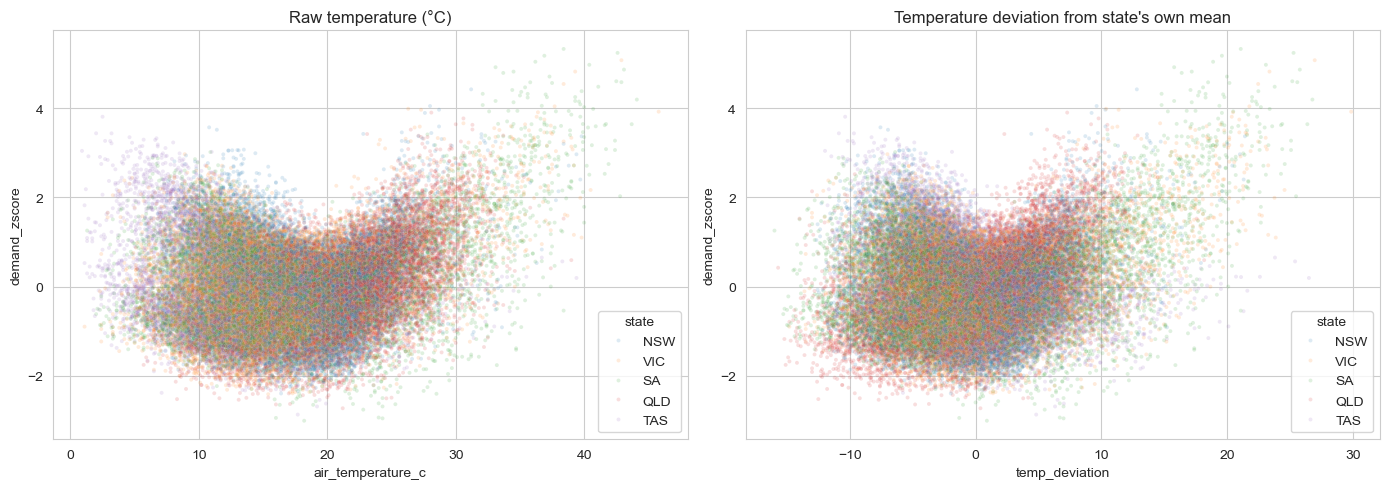

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=sample_df, x="air_temperature_c", y="demand_zscore",
                 hue="state", alpha=0.15, s=8, ax=axes[0])
axes[0].set_title("Raw temperature (\u00b0C)")

sns.scatterplot(data=sample_df, x="temp_deviation", y="demand_zscore",
                 hue="state", alpha=0.15, s=8, ax=axes[1])
axes[1].set_title("Temperature deviation from state's own mean")

plt.tight_layout()
plt.show()

### High-demand days (top quartile per state) vs. temperature deviation

Previews the planned KNN-classification supporting analysis -- checking whether high-demand days cluster at temperature extremes, and whether that clustering looks similar or different across states.

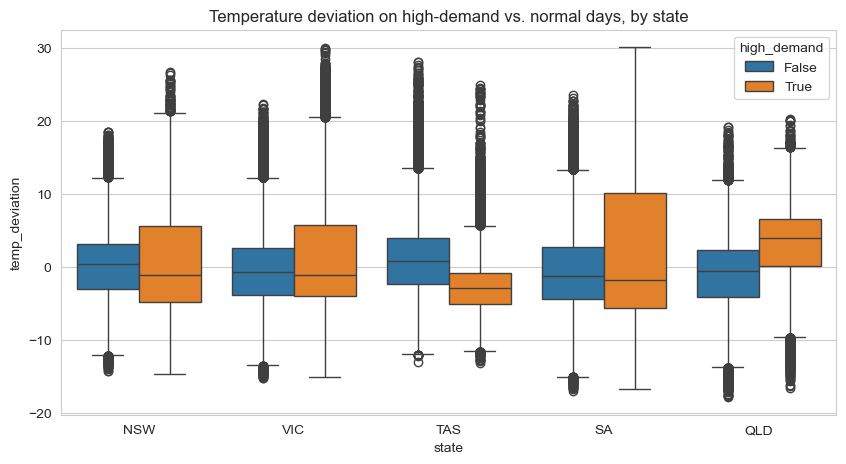

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_rq, x="state", y="temp_deviation", hue="high_demand", ax=ax)
ax.set_title("Temperature deviation on high-demand vs. normal days, by state")
plt.show()

# Notes 

- consider longitude and latitude comparisons for eda, include this in df_rq
- figure out time series snippets for graphing and plotting data, what would be reasonable
- note that IQR outlier removal should be used, have sanity checks to see how much of the data is removed (%)
- CONSIDER IMPUTATION WHERE NECESSARY - IF ITS LIKE 20% OF DATA PERHAPS IMPUTE - TAKE SNAPSHOTS OF TIME DATA AND USE KNN IMPUTATION TO BE MORE REPRESENTATIVE HOWEVER CONSIDER THAT IT MAY BE SUBJECT TO NOISE WHEN APPLIED TO THE WHOLE DATASET AND PUT THAT IN THE MARKDOWNS 
- Things like temperature may have dummy variables such as 9999 etc... look out for those as they may skew data - need to capute sensor erros/ mistakes in data
- RETHINKK FEATURE SELECTION AND ENGINEERING - RE-ENTER THE ORIGINAL RESEARCH QUESTION AND FIRGURE OUT FINAL DATA FRAME WITH ALL FEATURES
- START EDA ASAP, I WANT TO LOOK AT REGIONAL DIFFERENCES, PERHAPS A HEAT MAP OF LATTITUDE AND LONGITUDE OR SOME SCATTER PLOT OR BOX PLOTS OF A FEW FEATURES AND COMPARING THEM
- FIND OUT SUGGESTED MODELS FOR THIS RESEARCH QUESTION - MOST LIEKLY KNN CLASSIFICATION TO SUPPORT RESULTS 

# OTHER NOTES TO CIRCLE BACK TO 
1. Establish the baseline shape, per state

Plot demand vs. temperature as a scatter (or 2D density/hexbin, given your data volume) separately for each state — this is the first thing that'll tell you if the U-shaped/V-shaped relationship we discussed even holds consistently, or looks different in QLD vs TAS.
Fit a simple polynomial trend line on top of each state's scatter, purely visually at this stage — gives you an early read on whether the curvature differs (e.g. does TAS show a steep heating-side slope but flat cooling side, while QLD shows the reverse).

2. Normalize demand before comparing states

As flagged earlier — raw MW isn't comparable across states (NSW's demand dwarfs TAS's). Convert to a demand anomaly (z-score or % deviation from each state's own mean) before any cross-state comparison. This is the single most important EDA step for your specific RQ, since without it you can't tell if a "bigger" slope is real sensitivity or just bigger raw numbers.

3. Control for known confounders visually first

Facet your temperature-vs-demand-anomaly plots by weekday/weekend and by season, per state. This helps you see whether apparent state differences are actually just, say, TAS having a different weekday/weekend mix in your temperature range, before you trust a regression coefficient.

4. Quantify temperature "extremeness" per state

Each state has a different climate baseline — 30°C is unremarkable in QLD but extreme in TAS. Consider expressing temperature as a deviation from that state's own average/comfortable range, not just raw °C, so "sensitivity" is measured on a comparable footing.
Modelling — mapped specifically to this RQ

Step 1: Per-state polynomial/multivariate regression (your core technique)

Fit demand_anomaly ~ temperature + temperature² + day_of_week + time_of_day separately for each state, then compare the fitted curves and coefficients side by side. This directly answers "does the relationship differ" in the most interpretable way — you can literally show 5 curves on one plot.
Alternative/complementary approach: one pooled multivariate regression with a state × temperature interaction term (demand_anomaly ~ temperature * state + ...). This gives you a formal statistical test (is the interaction term significant?) rather than just "the curves look different" — worth doing both, since the interaction model gives you a p-value/significance claim for your conclusion, while the per-state models give you the intuitive plot for your presentation.

Step 2: Regularisation (as a validation check, not a compulsory step)

Once you add day-of-week, season, and temperature² terms together, some predictors will be correlated (temperature and temperature² especially). Ridge regression here is a reasonable, well-justified addition — it stabilizes those coefficients so your "sensitivity" comparison across states isn't distorted by multicollinearity. This is a good thing to mention even briefly in your mock as a "planned refinement."

Step 3: Random forest as a robustness check

Fit a random forest per state (or one pooled forest with state as a feature) predicting demand from temperature + other variables, then pull feature importance and partial dependence plots. If the tree-based model's temperature-demand relationship shape roughly agrees with your regression curves per state, that's a strong, defensible claim — two very different modelling approaches agreeing gives your conclusion real weight, which is exactly the "critical evaluation" the final rubric's top band is looking for.

Step 4: KNN imputation — where it fits for you specifically

Not central to this RQ's answer, but relevant to how clean your inputs are: use it during preprocessing to fill scattered gaps in your temperature variables per station (rather than dropping rows), so your per-state sample sizes stay large and comparable — small/uneven sample sizes between states would itself be a confound in a "compare sensitivity across states" analysis.